In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric

In [2]:
data=pd.read_csv("Service_requests_data_Delhi.csv")

In [3]:
data.head()

,created_date,Delhi_0,Delhi_1,Delhi_10,Delhi_2,Delhi_3,Delhi_4,Delhi_5,Delhi_6,Delhi_7,Delhi_8,Delhi_9
0,13/09/22,21,22,16,35,33,23,32,6,8,4,35
1,14/09/22,39,27,16,51,43,60,35,17,19,4,41
2,15/09/22,80,103,44,115,51,93,95,13,46,15,132
3,16/09/22,228,210,109,221,114,229,196,31,106,39,176
4,17/09/22,238,182,96,189,150,190,167,27,88,50,172


In [4]:
data["created_date"]=pd.to_datetime(data["created_date"],format="%d/%m/%y")
data=data.sort_values("created_date")
data.head()

,created_date,Delhi_0,Delhi_1,Delhi_10,Delhi_2,Delhi_3,Delhi_4,Delhi_5,Delhi_6,Delhi_7,Delhi_8,Delhi_9
0,2022-09-13,21,22,16,35,33,23,32,6,8,4,35
1,2022-09-14,39,27,16,51,43,60,35,17,19,4,41
2,2022-09-15,80,103,44,115,51,93,95,13,46,15,132
3,2022-09-16,228,210,109,221,114,229,196,31,106,39,176
4,2022-09-17,238,182,96,189,150,190,167,27,88,50,172


In [5]:
data.shape

(208, 12)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   created_date  208 non-null    datetime64[ns]
 1   Delhi_0       208 non-null    int64         
 2   Delhi_1       208 non-null    int64         
 3   Delhi_10      208 non-null    int64         
 4   Delhi_2       208 non-null    int64         
 5   Delhi_3       208 non-null    int64         
 6   Delhi_4       208 non-null    int64         
 7   Delhi_5       208 non-null    int64         
 8   Delhi_6       208 non-null    int64         
 9   Delhi_7       208 non-null    int64         
 10  Delhi_8       208 non-null    int64         
 11  Delhi_9       208 non-null    int64         
dtypes: datetime64[ns](1), int64(11)
memory usage: 19.6 KB


In [7]:
data.isnull().sum()

,0
created_date,0
Delhi_0,0
Delhi_1,0
Delhi_10,0
Delhi_2,0
Delhi_3,0
Delhi_4,0
Delhi_5,0
Delhi_6,0
Delhi_7,0


In [8]:
data.describe()

,created_date,Delhi_0,Delhi_1,Delhi_10,Delhi_2,Delhi_3,Delhi_4,Delhi_5,Delhi_6,Delhi_7,Delhi_8,Delhi_9
count,208,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000
mean,2022-12-25 12:00:00,162.250000,144.836538,87.774038,167.442308,119.793269,154.625000,146.038462,26.735577,70.687500,49.730769,150.735577
min,2022-09-13 00:00:00,21.000000,22.000000,16.000000,35.000000,33.000000,23.000000,32.000000,3.000000,8.000000,4.000000,35.000000
25%,2022-11-03 18:00:00,139.000000,121.750000,73.000000,140.750000,103.750000,134.000000,126.500000,19.000000,55.750000,38.750000,124.500000
50%,2022-12-25 12:00:00,158.000000,143.500000,85.000000,173.000000,120.000000,151.500000,147.500000,26.000000,69.000000,47.000000,146.000000
75%,2023-02-15 06:00:00,186.500000,169.750000,101.000000,196.250000,136.250000,177.000000,170.000000,32.000000,84.000000,59.000000,173.250000
max,2023-04-08 00:00:00,374.000000,262.000000,156.000000,309.000000,241.000000,266.000000,316.000000,91.000000,135.000000,133.000000,309.000000
std,NaN,42.532227,42.115234,22.085952,47.465182,28.145079,39.211476,38.995955,10.322448,22.547501,18.510595,42.065997


In [9]:
data.duplicated().sum()

np.int64(0)

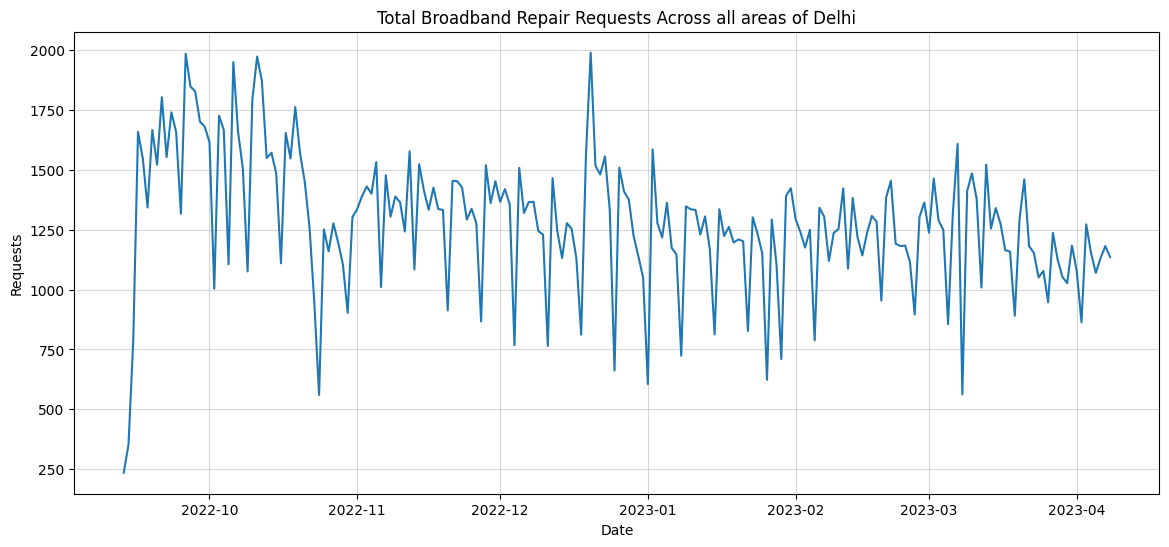

In [10]:
area_cols = data.columns[1:]
data['total_requests']=data[area_cols].sum(axis=1)

plt.figure(figsize=(14,6))
plt.plot(data['created_date'],data['total_requests'])
plt.title("Total Broadband Repair Requests Across all areas of Delhi")
plt.xlabel("Date")
plt.ylabel("Requests")
plt.grid(alpha=0.5)
plt.show()


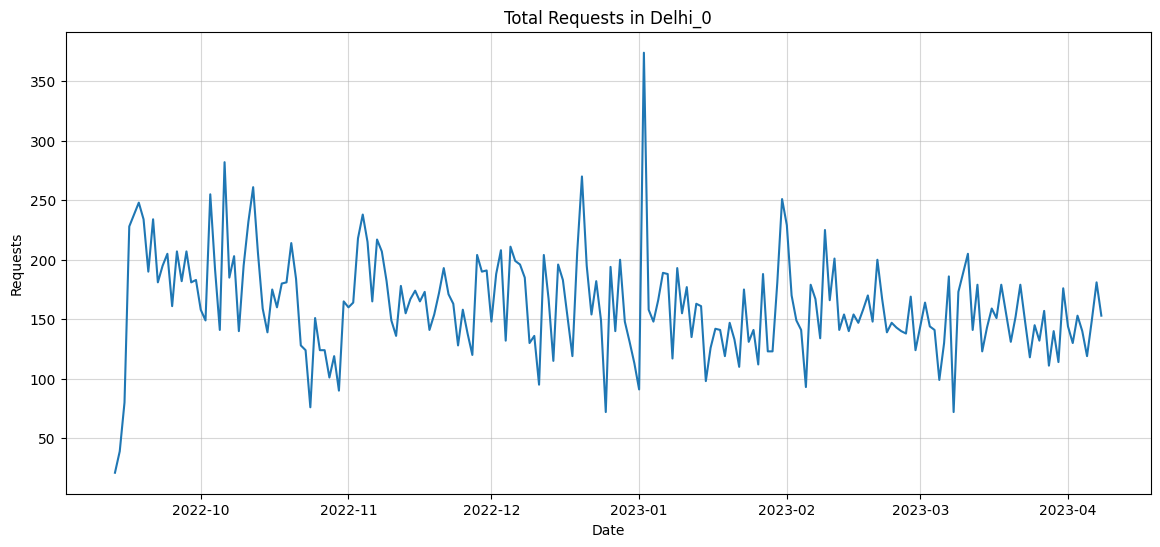

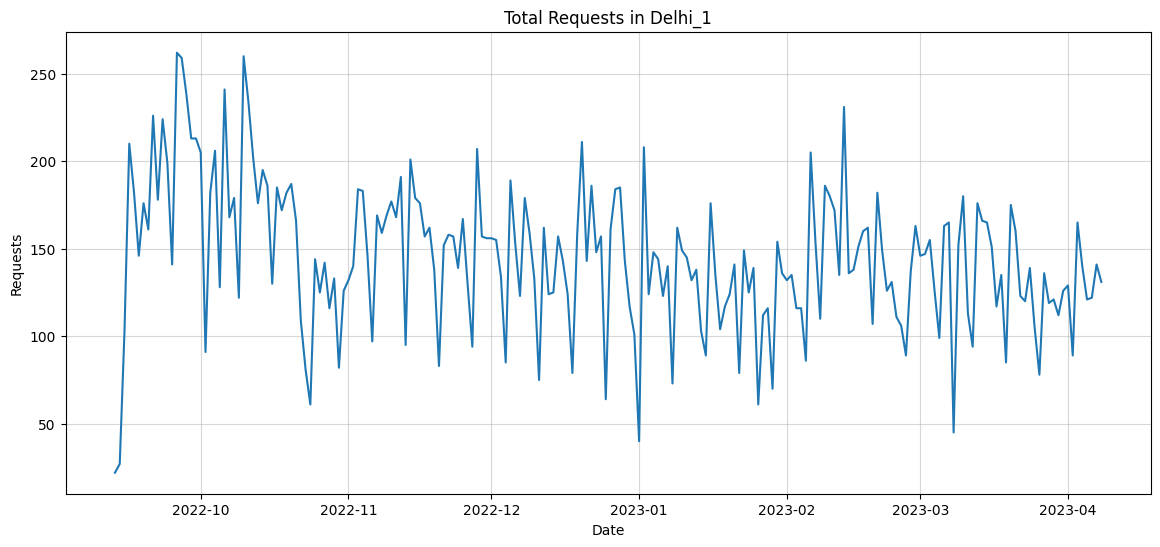

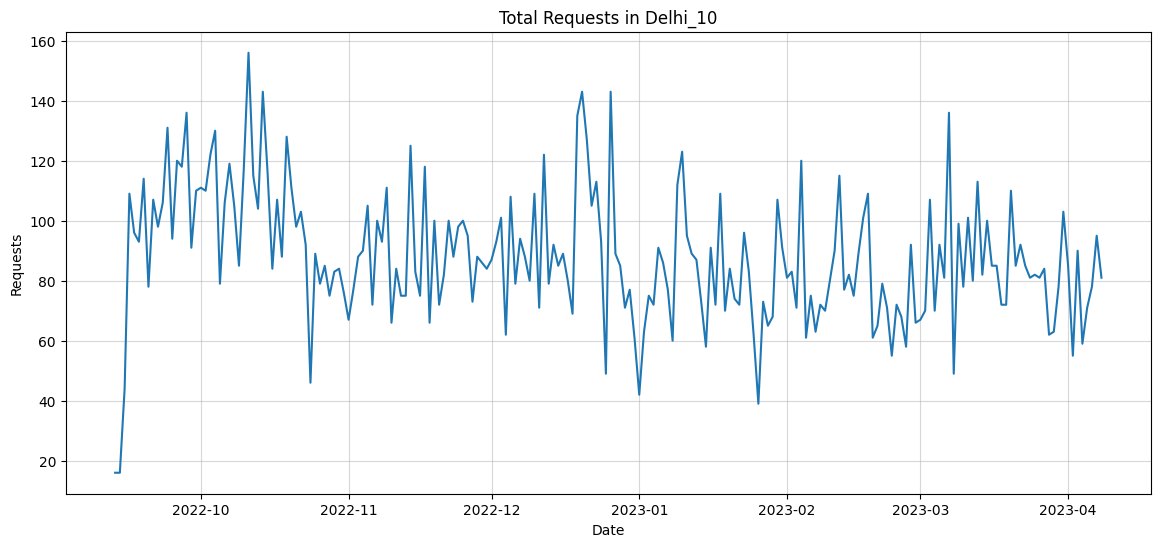

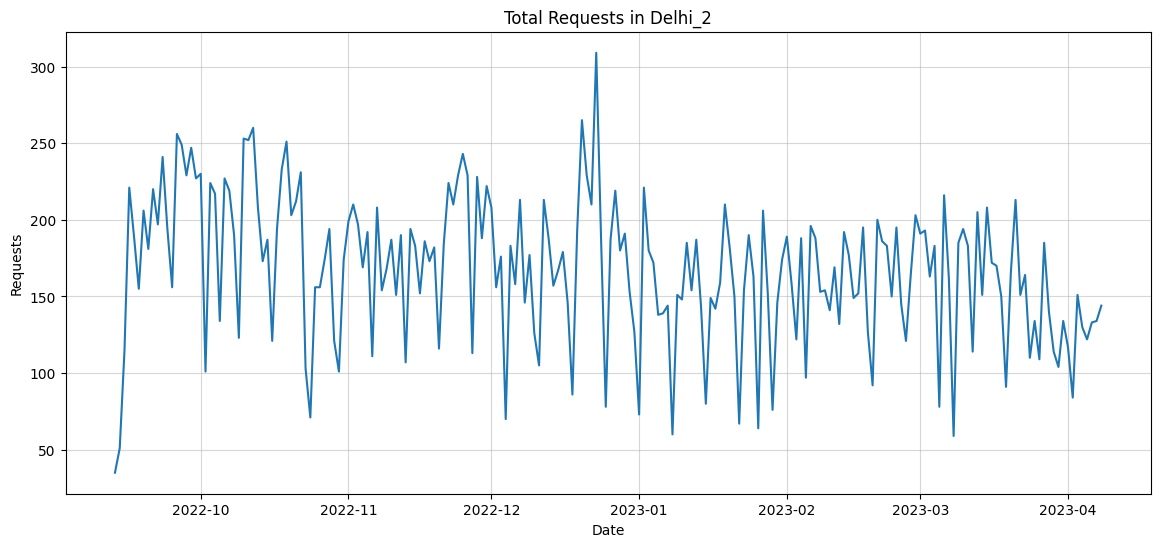

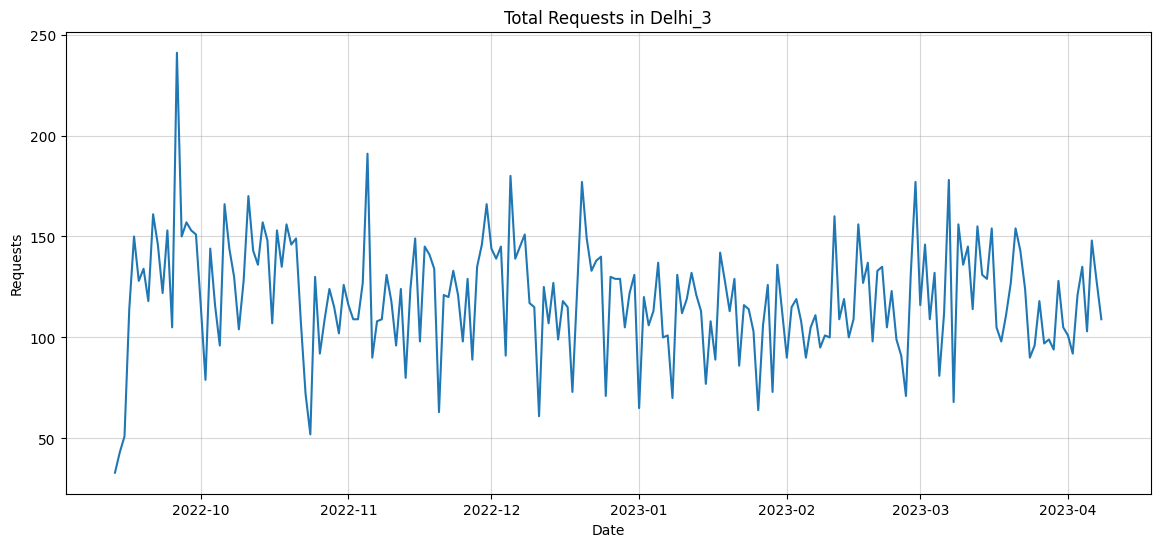

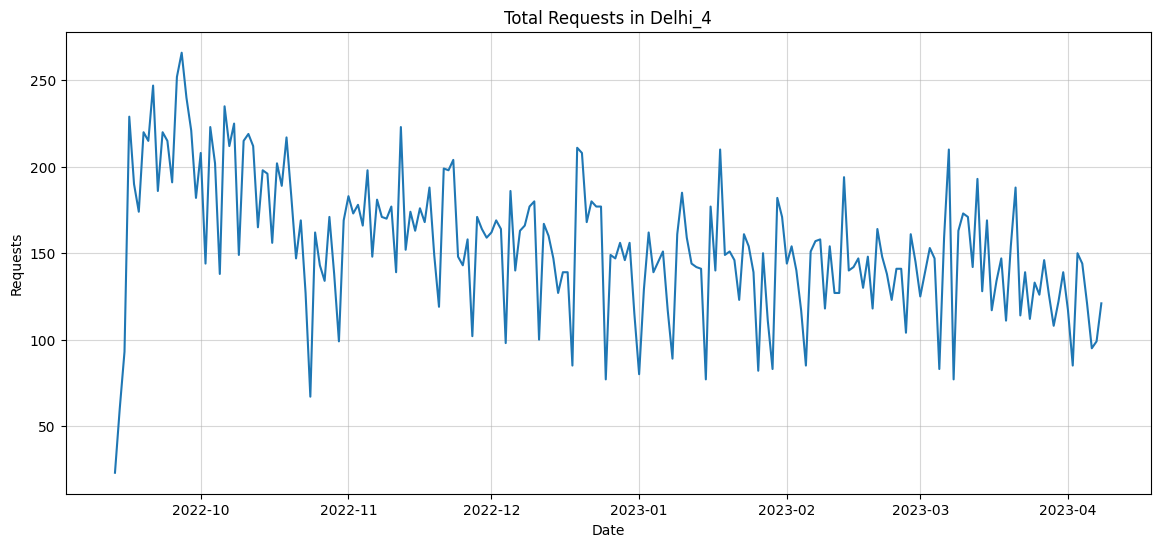

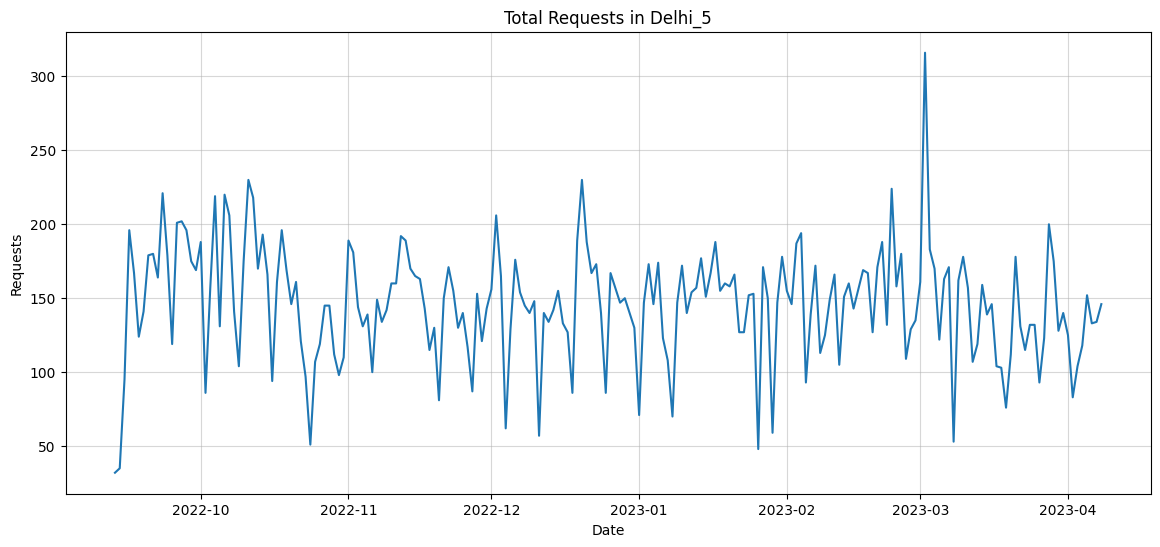

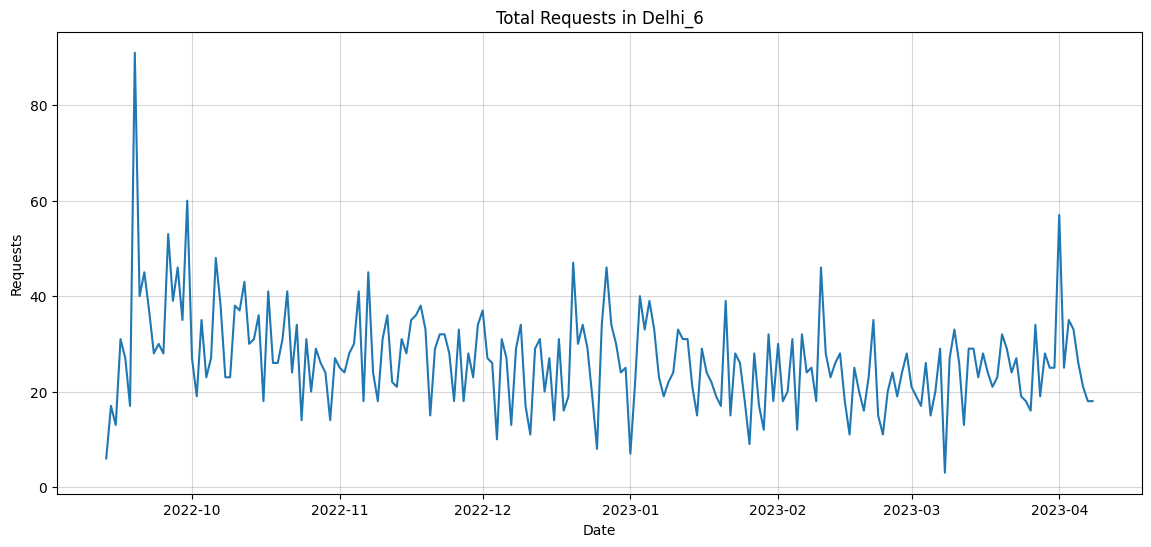

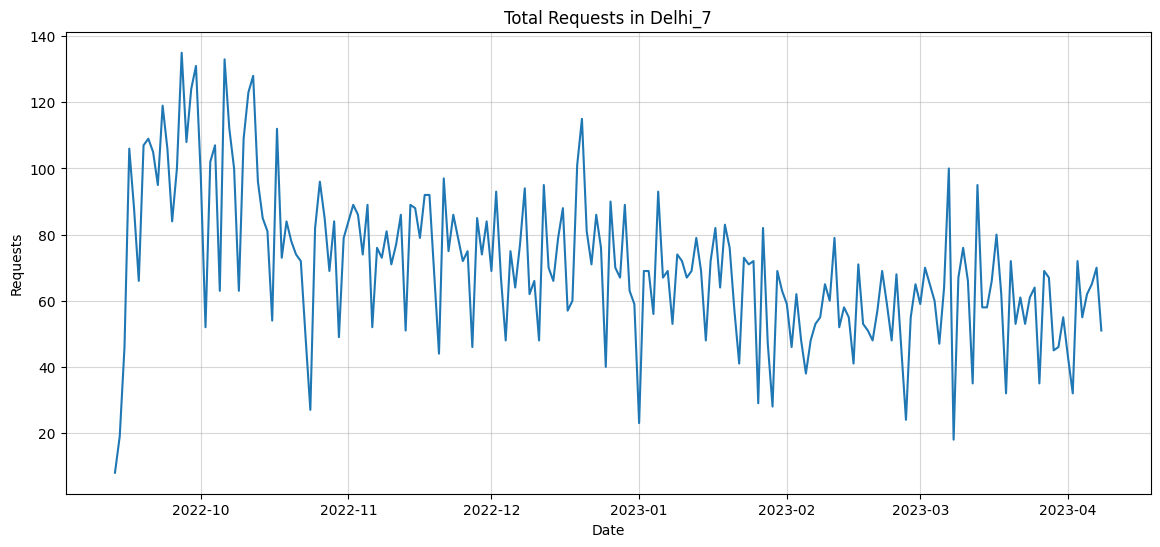

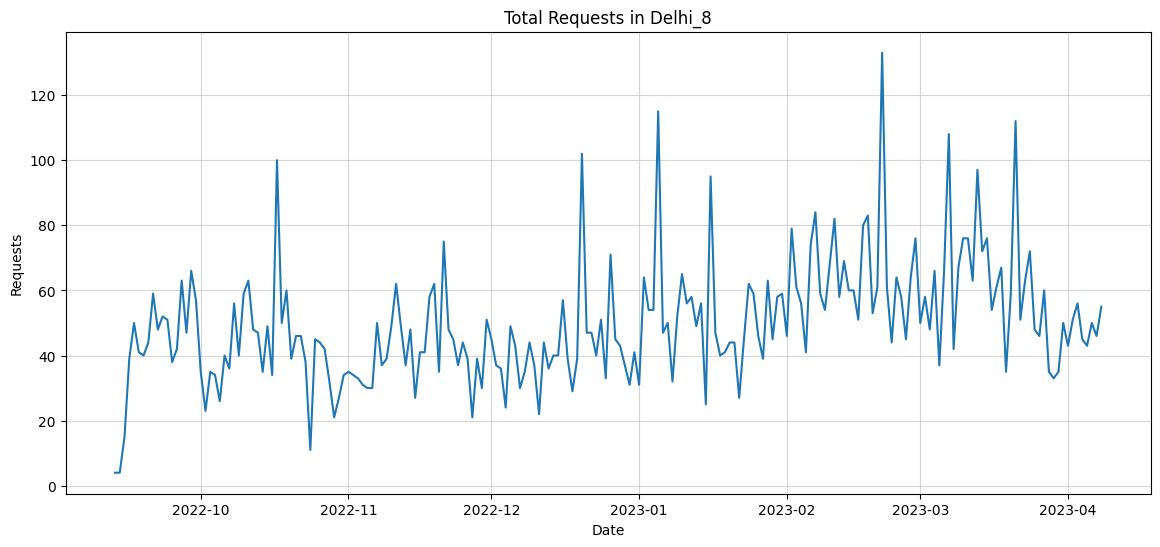

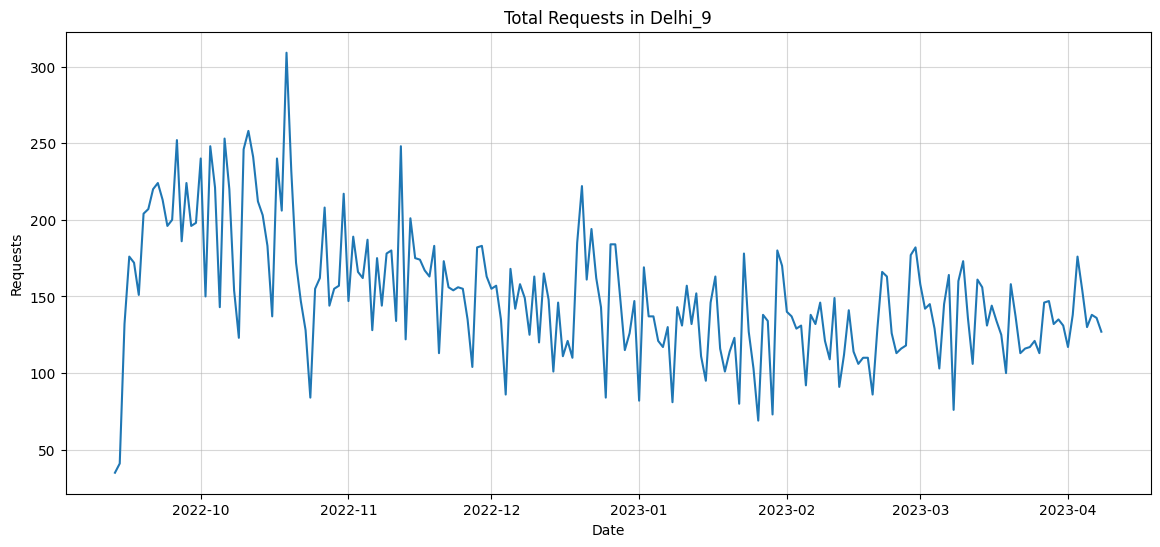

In [11]:
for i in area_cols:
    plt.figure(figsize=(14,6))
    plt.plot(data['created_date'],data[i])
    plt.title(f"Total Requests in {i}")
    plt.xlabel("Date")
    plt.ylabel("Requests")
    plt.grid(alpha=0.5)
    plt.show()

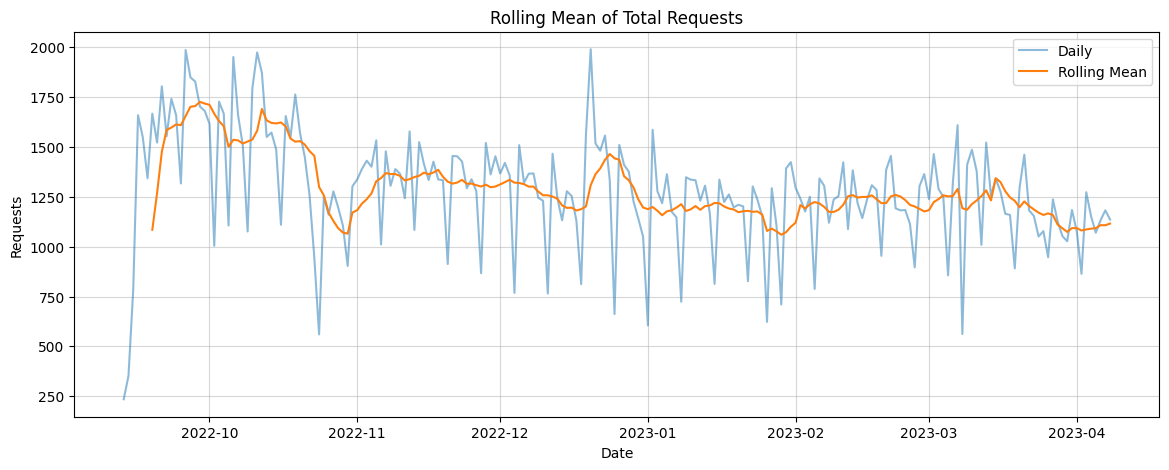

In [12]:
data['roll_mean'] = data['total_requests'].rolling(7).mean()

plt.figure(figsize=(14,5))
plt.plot(data['created_date'],data['total_requests'],alpha=0.5,label='Daily')
plt.plot(data['created_date'],data['roll_mean'], label='Rolling Mean')
plt.title('Rolling Mean of Total Requests')
plt.xlabel('Date')
plt.ylabel('Requests')
plt.grid(alpha=0.5)
plt.legend()
plt.show()

In [13]:
data.head(10)

,created_date,Delhi_0,Delhi_1,Delhi_10,Delhi_2,Delhi_3,Delhi_4,Delhi_5,Delhi_6,Delhi_7,Delhi_8,Delhi_9,total_requests,roll_mean
0,2022-09-13,21,22,16,35,33,23,32,6,8,4,35,235,NaN
1,2022-09-14,39,27,16,51,43,60,35,17,19,4,41,352,NaN
2,2022-09-15,80,103,44,115,51,93,95,13,46,15,132,787,NaN
3,2022-09-16,228,210,109,221,114,229,196,31,106,39,176,1659,NaN
4,2022-09-17,238,182,96,189,150,190,167,27,88,50,172,1549,NaN
5,2022-09-18,248,146,93,155,128,174,124,17,66,41,151,1343,NaN
6,2022-09-19,234,176,114,206,134,220,141,91,107,40,204,1667,1084.571429
7,2022-09-20,190,161,78,181,118,215,179,40,109,44,207,1522,1268.428571
8,2022-09-21,234,226,107,220,161,247,180,45,105,59,220,1804,1475.857143
9,2022-09-22,181,178,98,197,146,186,164,37,95,48,224,1554,1585.428571


Total requests in each area throughout the time period:
 Delhi_2     34828
Delhi_0     33748
Delhi_4     32162
Delhi_9     31353
Delhi_5     30376
Delhi_1     30126
Delhi_3     24917
Delhi_10    18257
Delhi_7     14703
Delhi_8     10344
Delhi_6      5561
dtype: int64


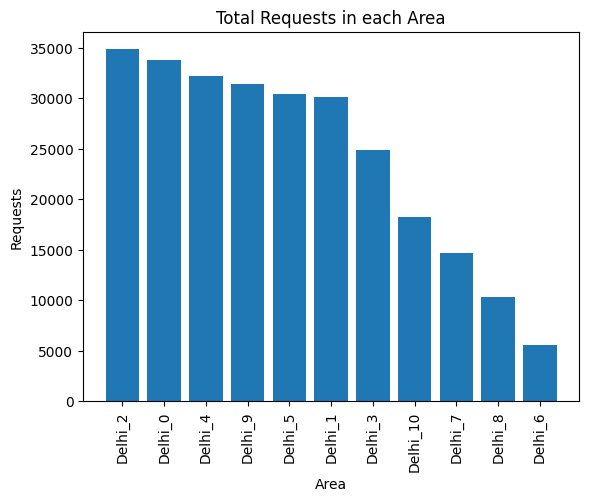

In [14]:
total=data[area_cols].sum().sort_values(ascending=False)
print("Total requests in each area throughout the time period:\n",total)
plt.bar(total.index,total.values)
plt.xticks(rotation=90)
plt.title("Total Requests in each Area")
plt.xlabel("Area")
plt.ylabel("Requests")
plt.show()

Delhi_2     47.465182
Delhi_0     42.532227
Delhi_1     42.115234
Delhi_9     42.065997
Delhi_4     39.211476
Delhi_5     38.995955
Delhi_3     28.145079
Delhi_7     22.547501
Delhi_10    22.085952
Delhi_8     18.510595
Delhi_6     10.322448
dtype: float64


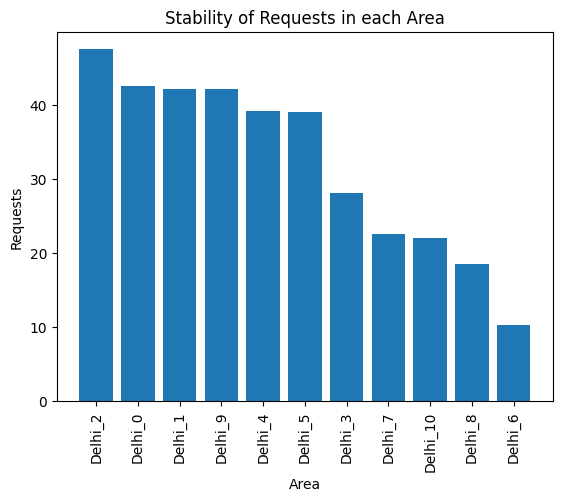

In [15]:
stability=data[area_cols].std().sort_values(ascending=False)
print(stability)
plt.bar(stability.index,stability.values)
plt.xticks(rotation=90)
plt.title("Stability of Requests in each Area")
plt.xlabel("Area")
plt.ylabel("Requests")
plt.show()

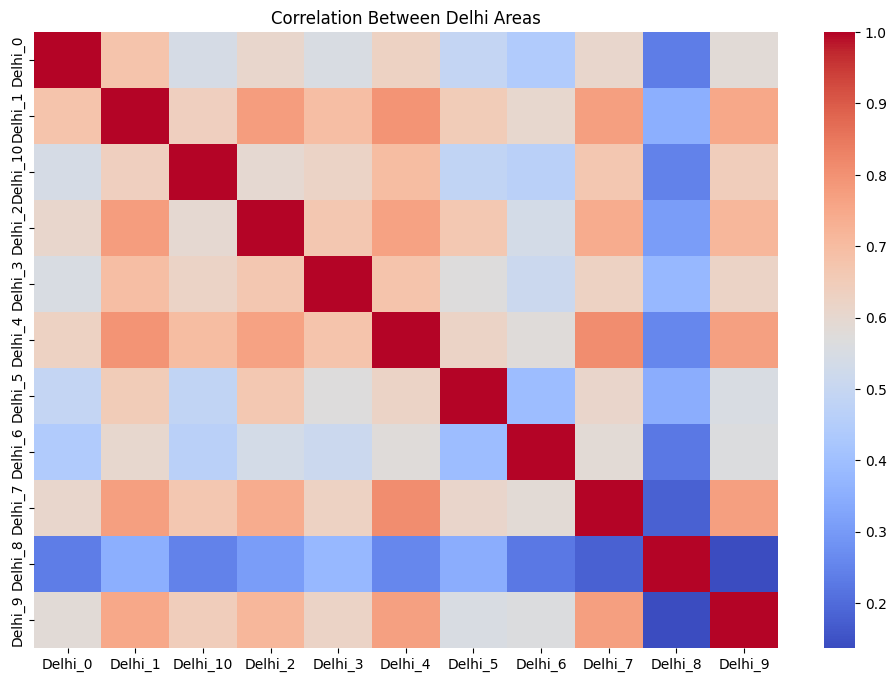

In [16]:
plt.figure(figsize=(12,8))
sns.heatmap(data[area_cols].corr(),cmap="coolwarm")
plt.title("Correlation Between Delhi Areas")
plt.show()

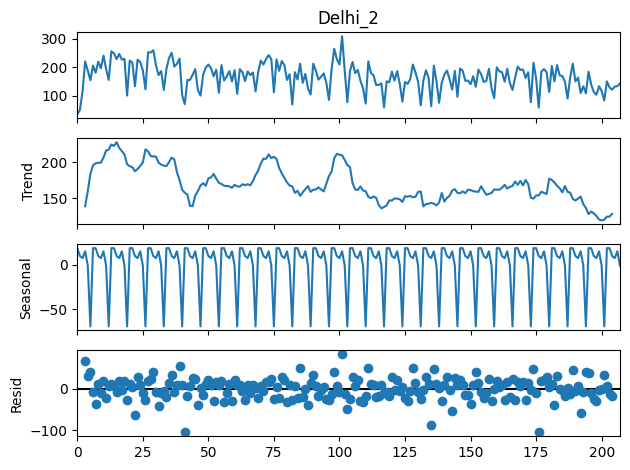

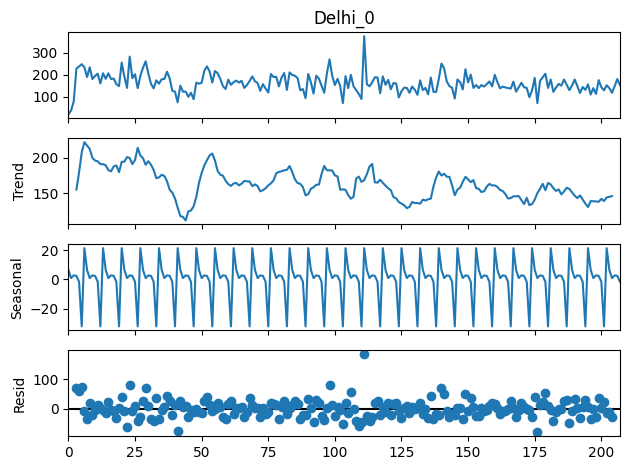

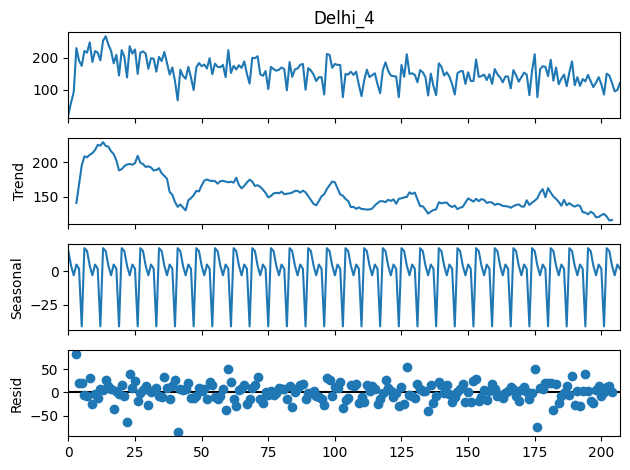

In [17]:
top_areas = total.head(3).index

for area in top_areas:
    result = seasonal_decompose(data[area], model='additive', period=7)
    result.plot()
    plt.show()


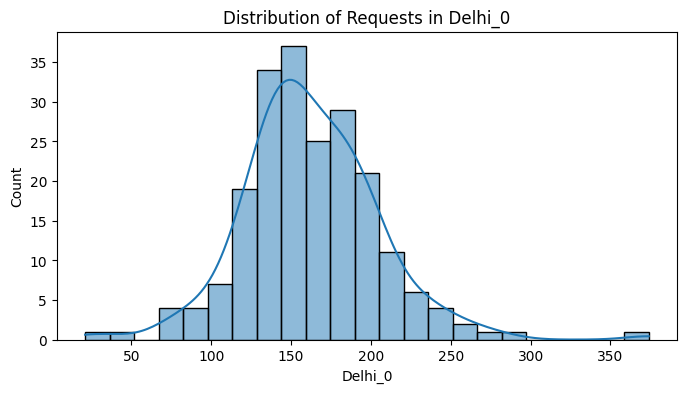

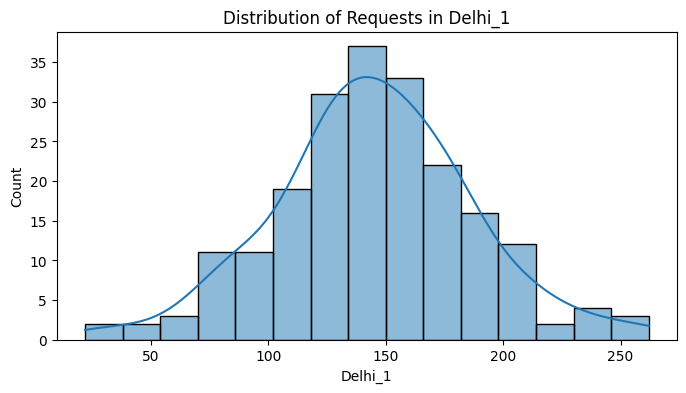

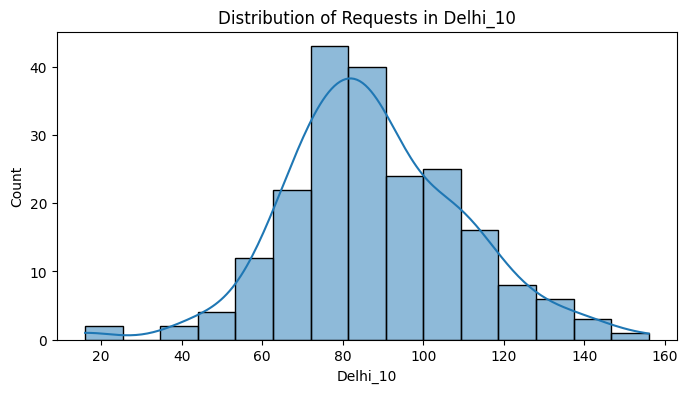

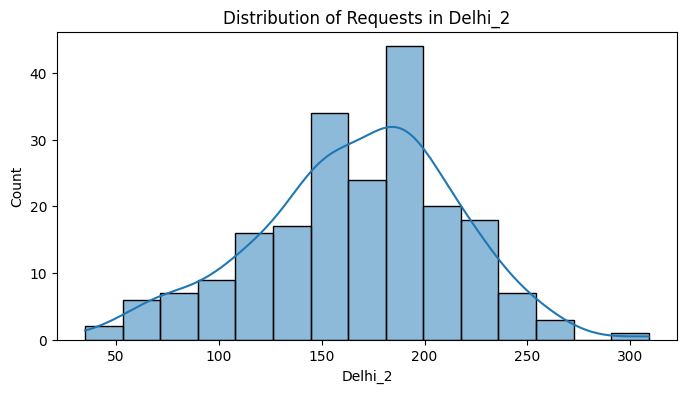

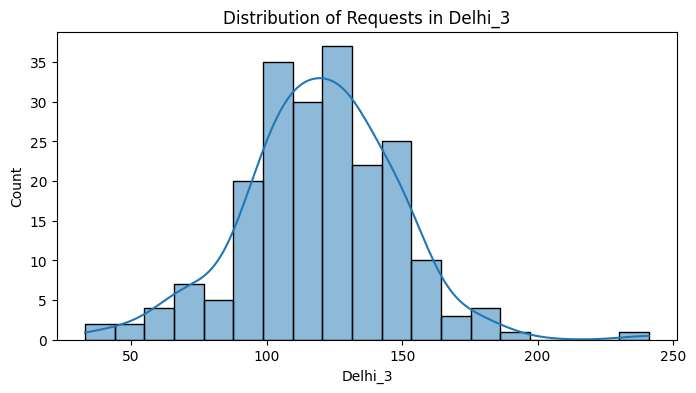

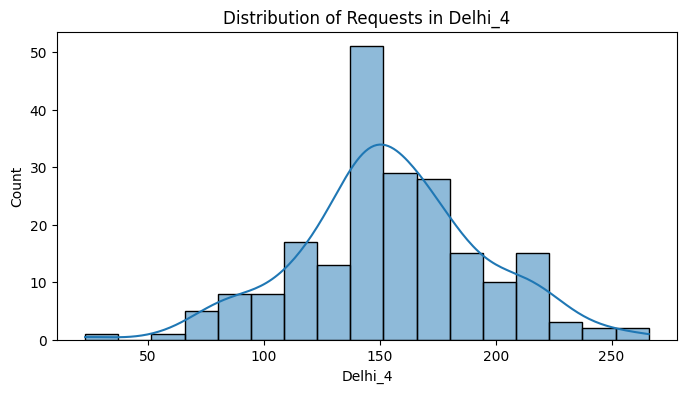

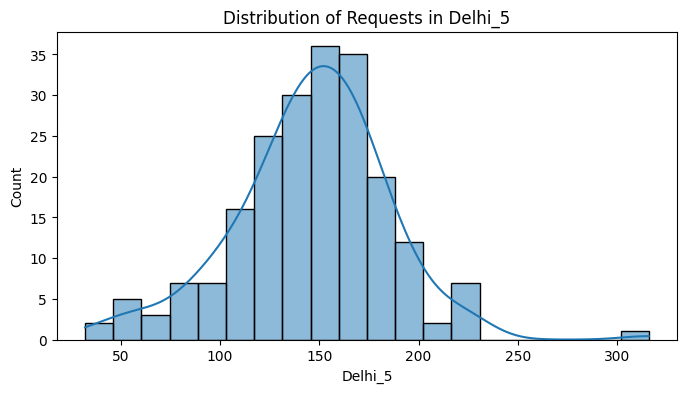

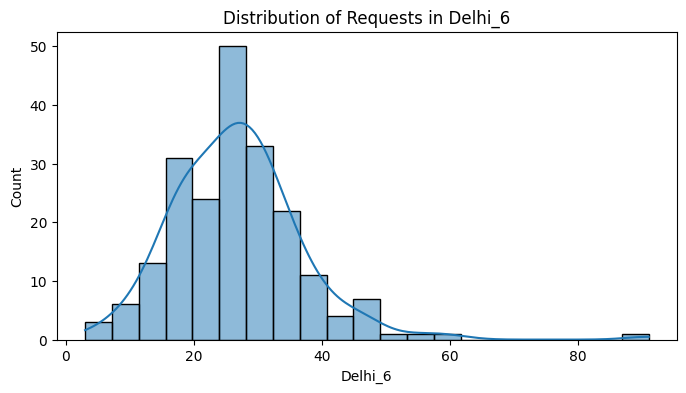

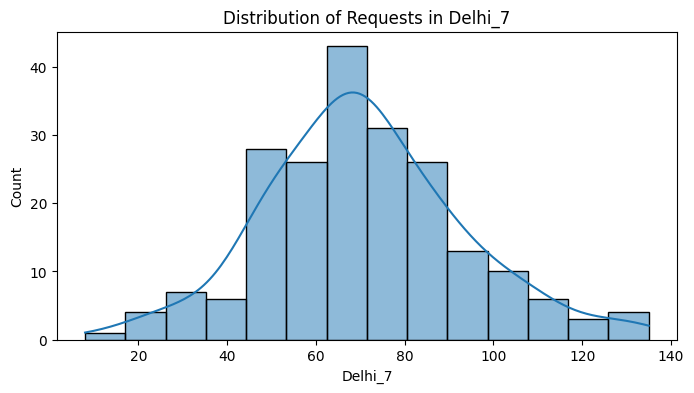

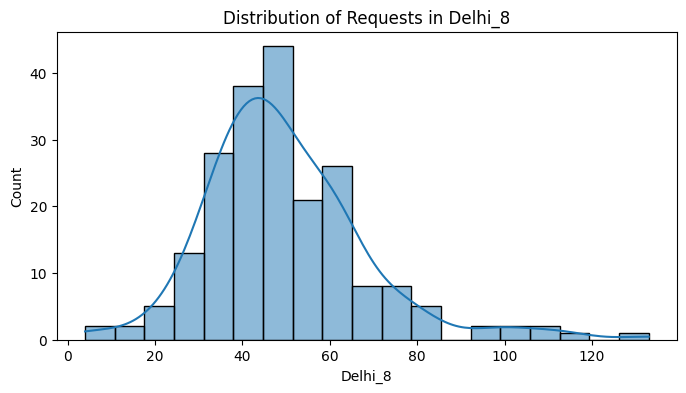

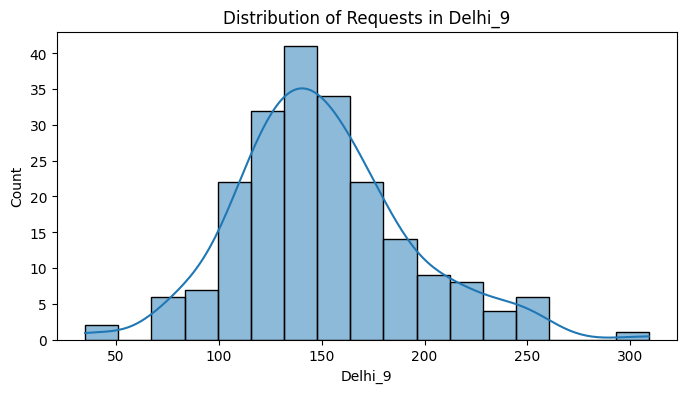

In [18]:
for col in area_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(data[col], kde=True)
    plt.title(f"Distribution of Requests in {col}")
    plt.show()


In [19]:
df=data.copy()
area="Delhi_4"
split=int(len(df)*0.8)
train=df.iloc[:split].copy()
test=df.iloc[split:].copy()

In [20]:
test["naive_pred"]=train[area].iloc[-1]

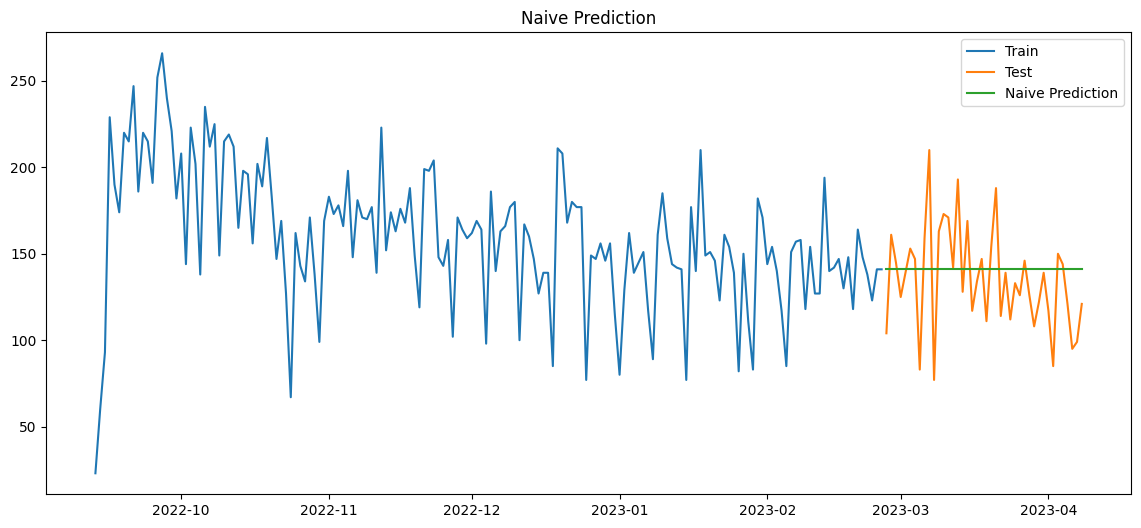

In [21]:
plt.figure(figsize=(14,6))
plt.plot(train["created_date"],train[area],label="Train")
plt.plot(test["created_date"],test[area],label="Test")
plt.plot(test["created_date"],test["naive_pred"],label="Naive Prediction")
plt.legend()
plt.title("Naive Prediction")
plt.show()

In [22]:
mae_naive = mean_absolute_error(test[area], test['naive_pred'])
rmse_naive = np.sqrt(mean_squared_error(test[area], test['naive_pred']))
smape_naive=100*(np.abs(test[area]-test['naive_pred'])/((np.abs(test[area])+np.abs(test['naive_pred']))/2)).mean()

print("Naive MAE:", mae_naive)
print("Naive RMSE:", rmse_naive)
print("Naive SMAPE:", smape_naive)

Naive MAE: 23.476190476190474
Naive RMSE: 29.61016556458111
Naive SMAPE: 17.553558233537363


In [23]:
window=7
train["ma"]=train[area].rolling(window).mean()
last_ma=train["ma"].dropna().iloc[-1]
test["ma_pred"]=last_ma

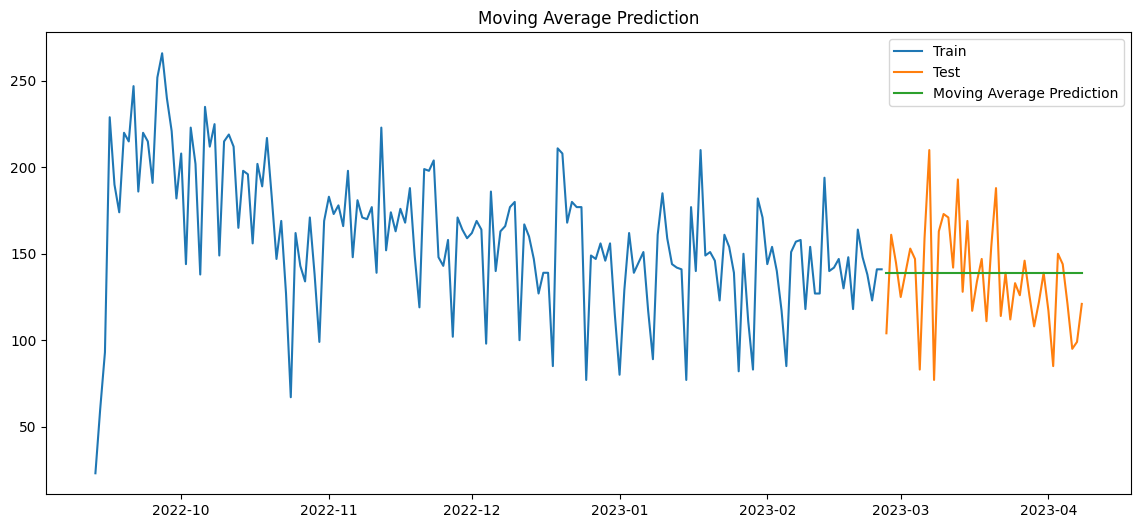

In [24]:
plt.figure(figsize=(14,6))
plt.plot(train["created_date"],train[area],label="Train")
plt.plot(test["created_date"],test[area],label="Test")
plt.plot(test["created_date"],test["ma_pred"],label="Moving Average Prediction")
plt.legend()
plt.title("Moving Average Prediction")
plt.show()

In [25]:
mae_ma=mean_absolute_error(test[area],test["ma_pred"])
rmse_ma=np.sqrt(mean_squared_error(test[area],test["ma_pred"]))
smape_ma=100*(np.abs(test[area]-test["ma_pred"])/((np.abs(test[area])+np.abs(test["ma_pred"]))/2)).mean()

print("Moving Average MAE:",mae_ma)
print("Moving Average RMSE:",rmse_ma)
print("Moving Average SMAPE:",smape_ma)

Moving Average MAE: 23.19047619047619
Moving Average RMSE: 29.30301463444788
Moving Average SMAPE: 17.358125243906


In [26]:
ses_model=SimpleExpSmoothing(train[area]).fit()
test["ses_pred"]=ses_model.forecast(len(test))

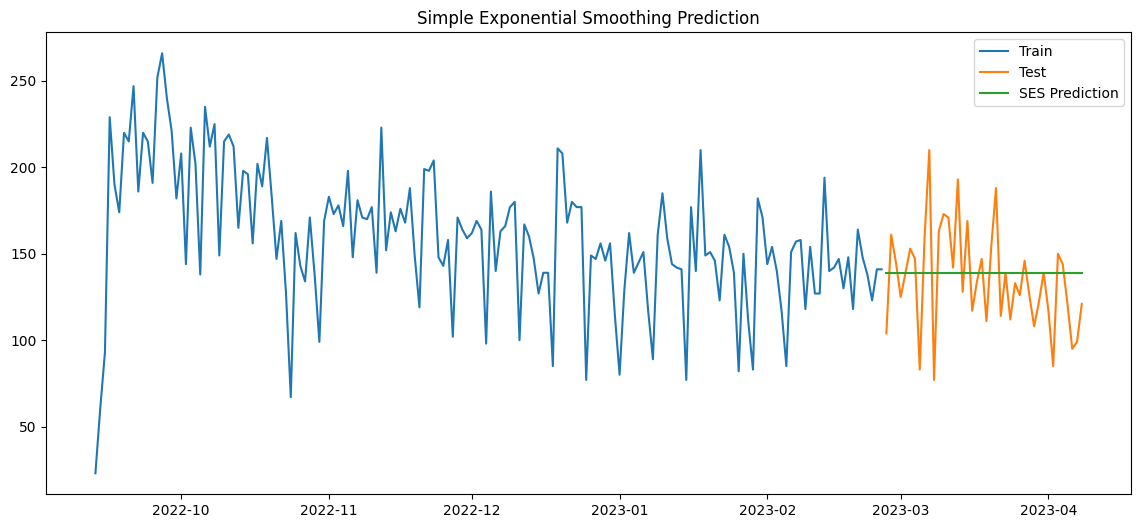

In [27]:
plt.figure(figsize=(14,6))
plt.plot(train["created_date"],train[area],label="Train")
plt.plot(test["created_date"],test[area],label="Test")
plt.plot(test["created_date"],test["ses_pred"],label="SES Prediction")
plt.legend()
plt.title("Simple Exponential Smoothing Prediction")
plt.show()

In [28]:
ses_mae=mean_absolute_error(test[area],test["ses_pred"])
ses_rmse=np.sqrt(mean_squared_error(test[area],test["ses_pred"]))
ses_smape=100*(np.abs(test[area]-test["ses_pred"])/((np.abs(test[area])+np.abs(test["ses_pred"]))/2)).mean()

print("SES MAE:",ses_mae)
print("SES RMSE:",ses_rmse)
print("SES SMAPE:",ses_smape)

SES MAE: 23.19047619047619
SES RMSE: 29.286540907353363
SES SMAPE: 17.358669173765755


In [29]:
es_model=ExponentialSmoothing(train[area],trend="add",seasonal="add",seasonal_periods=7).fit()
test["es_pred"]=es_model.forecast(len(test))

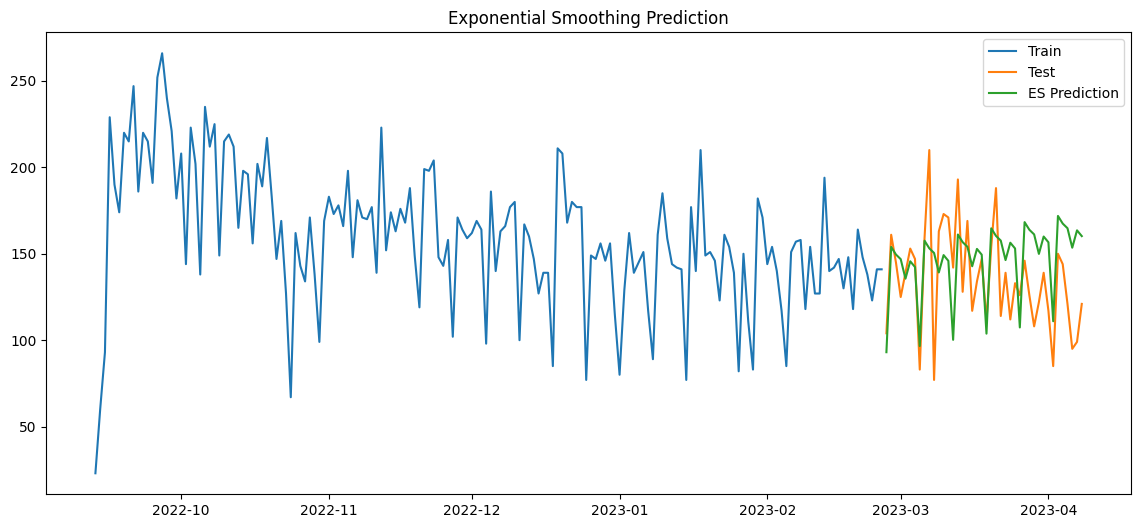

In [30]:
plt.figure(figsize=(14,6))
plt.plot(train["created_date"],train[area],label="Train")
plt.plot(test["created_date"],test[area],label="Test")
plt.plot(test["created_date"],test["es_pred"],label="ES Prediction")
plt.legend()
plt.title("Exponential Smoothing Prediction")
plt.show()

In [31]:
es_mae=mean_absolute_error(test[area],test["es_pred"])
es_rmse=np.sqrt(mean_squared_error(test[area],test["es_pred"]))
es_smape=100*(np.abs(test[area]-test["es_pred"])/((np.abs(test[area])+np.abs(test["es_pred"]))/2)).mean()

print("ES MAE:",es_mae)
print("ES RMSE:",es_rmse)
print("ES SMAPE:",es_smape)

ES MAE: 26.221454435405423
ES RMSE: 31.654981923071972
ES SMAPE: 19.12749126994769


In [32]:
result=adfuller(train[area])
print("ADF Statistic:",result[0])
print("p-value:",result[1])

ADF Statistic: -1.9393102489521177
p-value: 0.3138001805187327


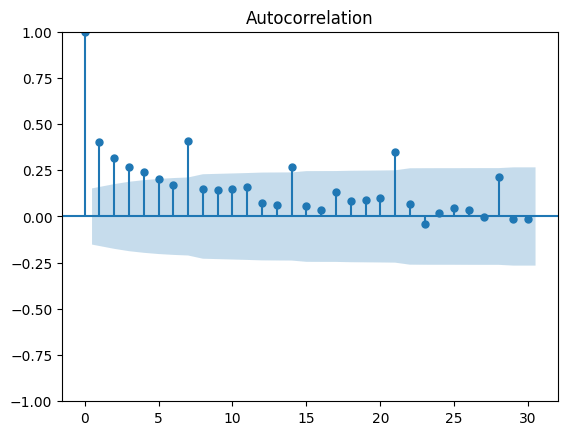

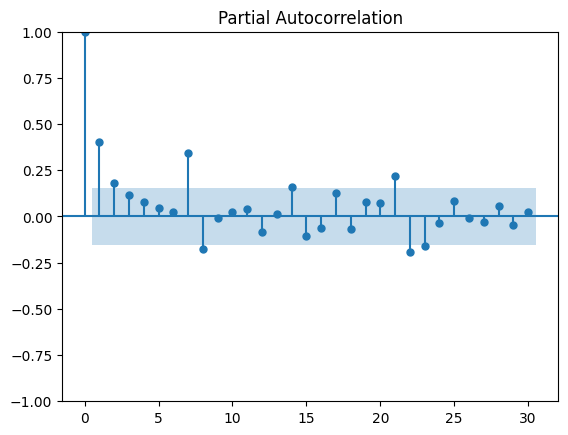

In [33]:
plot_acf(train[area],lags=30)
plt.show()
plot_pacf(train[area],lags=30)
plt.show()

In [34]:
arima_model=sm.tsa.ARIMA(train[area],order=(1,1,1))
result=arima_model.fit()
print(result.summary())

                               SARIMAX Results                                
Dep. Variable:                Delhi_4   No. Observations:                  166
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -823.781
Date:                Fri, 17 Apr 2026   AIC                           1653.562
Time:                        07:19:34   BIC                           1662.880
Sample:                             0   HQIC                          1657.344
                                - 166                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1476      0.105      1.411      0.158      -0.057       0.353
ma.L1         -0.8161      0.065    -12.578      0.000      -0.943      -0.689
sigma2      1264.0340    108.658     11.633      0.0

In [35]:
forecasting=result.predict(start=len(train),end=len(train)+len(test)-1,typ="levels")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


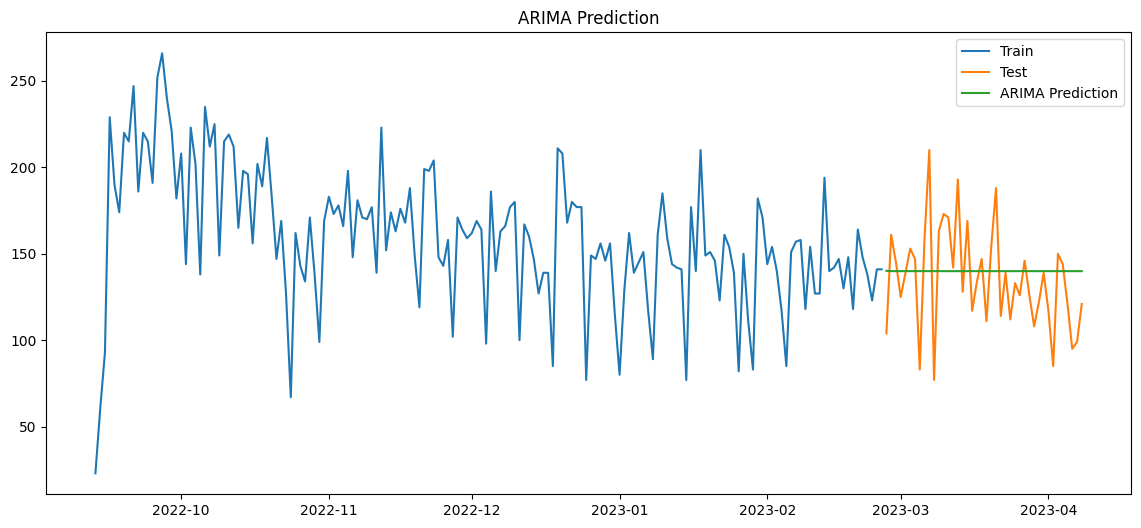

In [36]:
plt.figure(figsize=(14,6))
plt.plot(train["created_date"],train[area],label="Train")
plt.plot(test["created_date"],test[area],label="Test")
plt.plot(test["created_date"],forecasting,label="ARIMA Prediction")
plt.legend()
plt.title("ARIMA Prediction")
plt.show()

In [37]:
arima_mae=mean_absolute_error(test[area],forecasting)
arima_rmse=np.sqrt(mean_squared_error(test[area],forecasting))
arima_smape=100*(np.abs(test[area]-forecasting)/((np.abs(test[area])+np.abs(forecasting))/2)).mean()

print("ARIMA MAE:",arima_mae)
print("ARIMA RMSE:",arima_rmse)
print("ARIMA SMAPE:",arima_smape)

ARIMA MAE: 23.329637665104983
ARIMA RMSE: 29.436880281415927
ARIMA SMAPE: 17.453915156028206


In [38]:
sarima_model=sm.tsa.statespace.SARIMAX(train[area],order=(1,1,1),seasonal_order=(1,1,1,7))
result_sarima=sarima_model.fit()
print(result_sarima.summary())

                                     SARIMAX Results                                     
Dep. Variable:                           Delhi_4   No. Observations:                  166
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood                -764.592
Date:                           Fri, 17 Apr 2026   AIC                           1539.184
Time:                                   07:19:36   BIC                           1554.497
Sample:                                        0   HQIC                          1545.402
                                           - 166                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1067      0.218     -0.490      0.624      -0.533       0.320
ma.L1         -0.3695      0.211     -1.755

In [39]:
sarima_forecast=result_sarima.predict(start=len(train),end=len(train)+len(test)-1,typ="levels")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


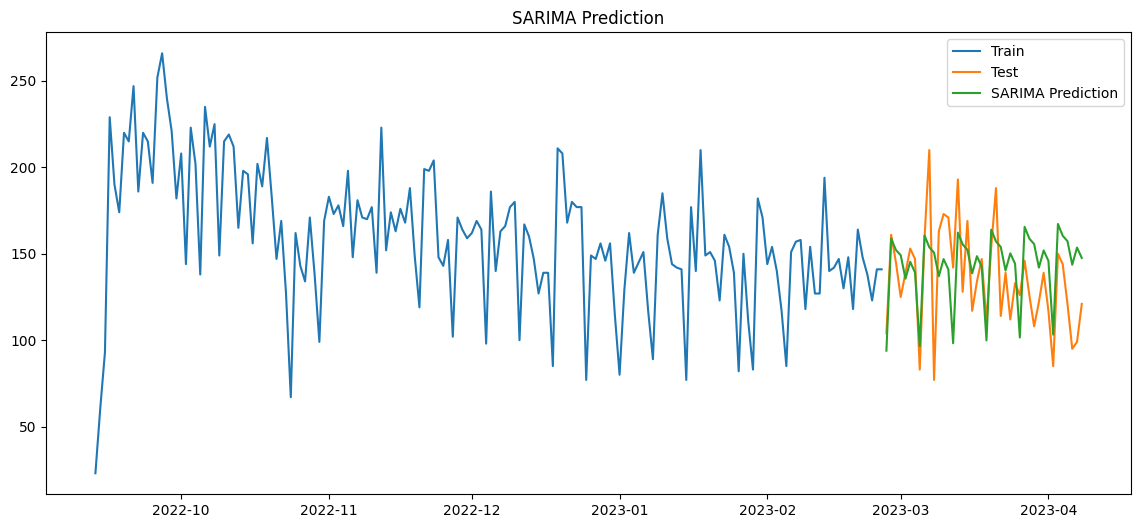

In [40]:
plt.figure(figsize=(14,6))
plt.plot(train["created_date"],train[area],label="Train")
plt.plot(test["created_date"],test[area],label="Test")
plt.plot(test["created_date"],sarima_forecast,label="SARIMA Prediction")
plt.legend()
plt.title("SARIMA Prediction")
plt.show()

In [41]:
sarima_mae=mean_absolute_error(test[area],sarima_forecast)
sarima_rmse=np.sqrt(mean_squared_error(test[area],sarima_forecast))
sarima_smape=100*(np.abs(test[area]-sarima_forecast)/((np.abs(test[area])+np.abs(sarima_forecast))/2)).mean()

print("SARIMA MAE:",sarima_mae)
print("SARIMA RMSE:",sarima_rmse)
print("SARIMA SMAPE:",sarima_smape)

SARIMA MAE: 23.714606659500024
SARIMA RMSE: 28.809192179769465
SARIMA SMAPE: 17.58252061527639


In [42]:
df_prophet = data[['created_date', area]].rename(columns={
    'created_date': 'ds',
    area: 'y'
})

In [43]:
split=int(len(df_prophet) * 0.8)
train_p=df_prophet.iloc[:split].copy()
test_p=df_prophet.iloc[split:].copy()


In [44]:
prophet_model=Prophet(yearly_seasonality=False,weekly_seasonality=True,daily_seasonality=False)
prophet_model.fit(train_p)

In [45]:
future = prophet_model.make_future_dataframe(periods=len(test_p))
forecast = prophet_model.predict(future)

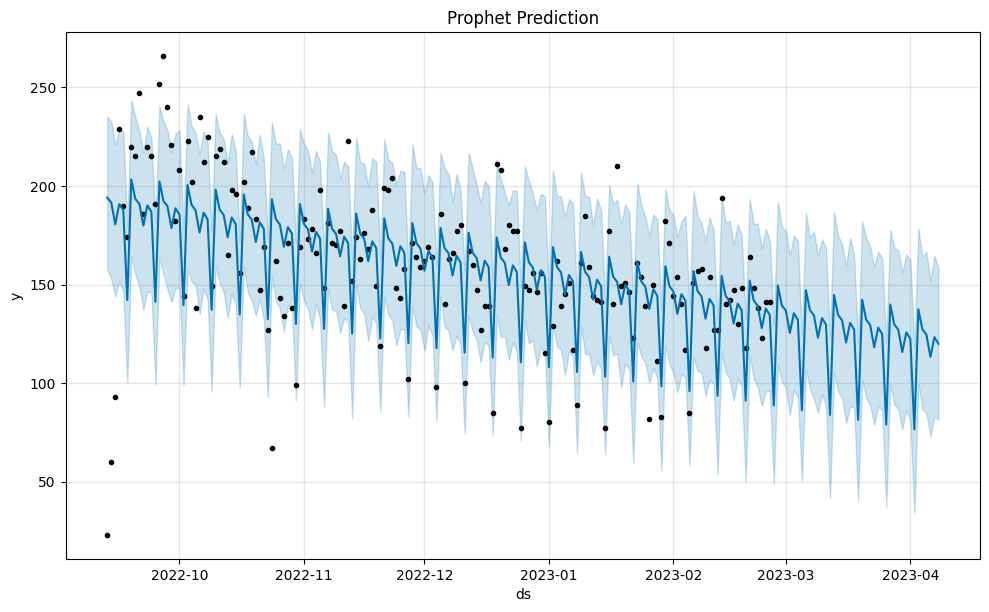

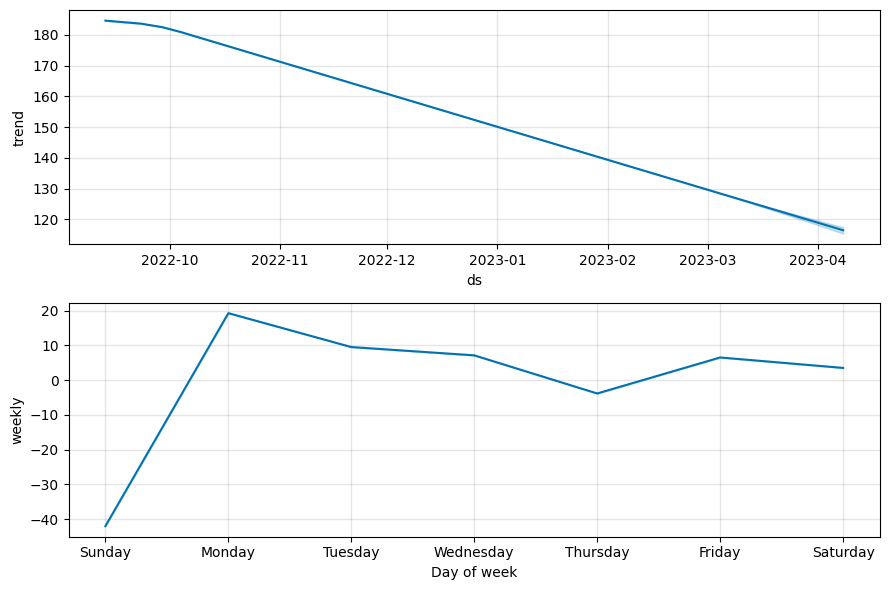

In [46]:
prophet_model.plot(forecast)
plt.title("Prophet Prediction")
plt.show()
prophet_model.plot_components(forecast)
plt.show()

In [47]:
pred = forecast.iloc[-len(test_p):]['yhat'].values

In [48]:
mae_prophet=mean_absolute_error(test_p['y'],pred)
rmse_prophet=np.sqrt(mean_squared_error(test_p['y'],pred))
smape_prophet=100*(np.abs(test_p['y']-pred)/((np.abs(test_p['y'])+np.abs(pred))/2)).mean()

print("Prophet MAE:",mae_prophet)
print("Prophet RMSE:",rmse_prophet)
print("Prophet SMAPE:",smape_prophet)

Prophet MAE: 20.89632185070679
Prophet RMSE: 27.575239262234668
Prophet SMAPE: 16.07174948090347


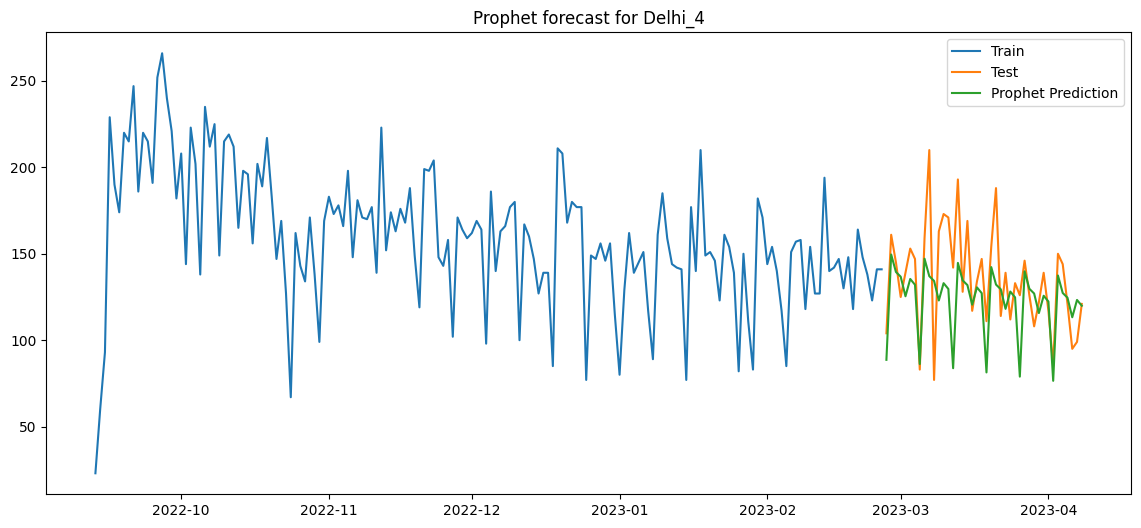

In [49]:
plt.figure(figsize=(14,6))
plt.plot(train_p['ds'],train_p['y'],label="Train")
plt.plot(test_p['ds'],test_p['y'],label="Test")
plt.plot(test_p['ds'],pred,label="Prophet Prediction")
plt.legend()
plt.title(f"Prophet forecast for {area}")
plt.show()

In [50]:
results = pd.DataFrame({"Model": ["Naive", "MovingAvg", "SES", "ES","ARIMA", "SARIMA", "Prophet"],
    "MAE": [mae_naive, mae_ma, ses_mae, es_mae,arima_mae, sarima_mae, mae_prophet],
    "RMSE": [rmse_naive, rmse_ma, ses_rmse, es_rmse,arima_rmse, sarima_rmse, rmse_prophet],
    "SMAPE": [smape_naive, smape_ma, ses_smape, es_smape,arima_smape, sarima_smape, smape_prophet]
})

print(results.sort_values("RMSE"))


       Model        MAE       RMSE      SMAPE
6    Prophet  20.896322  27.575239  16.071749
5     SARIMA  23.714607  28.809192  17.582521
2        SES  23.190476  29.286541  17.358669
1  MovingAvg  23.190476  29.303015  17.358125
4      ARIMA  23.329638  29.436880  17.453915
0      Naive  23.476190  29.610166  17.553558
3         ES  26.221454  31.654982  19.127491


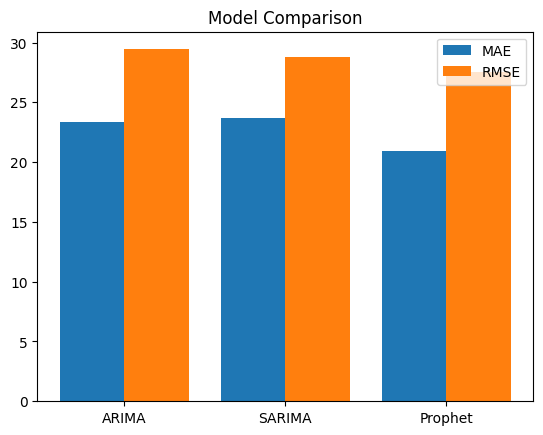

In [51]:
import matplotlib.pyplot as plt

models = ["ARIMA", "SARIMA", "Prophet"]
mae = [arima_mae, sarima_mae, mae_prophet]
rmse = [arima_rmse,sarima_rmse,rmse_prophet]

x = range(len(models))

plt.figure()
plt.bar(x, mae, width=0.4, label="MAE")
plt.bar([i + 0.4 for i in x], rmse, width=0.4, label="RMSE")

plt.xticks([i + 0.2 for i in x], models)
plt.title("Model Comparison")
plt.legend()

plt.show()

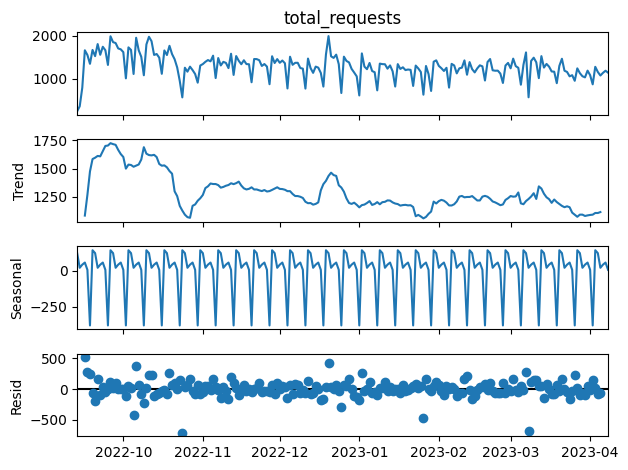

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# convert date column
df['created_date'] = pd.to_datetime(df['created_date'])

# set index
df.set_index('created_date', inplace=True)

# select time series
ts = df['total_requests']

# decomposition
result = seasonal_decompose(ts, model='additive', period=7)

# plot
result.plot()
plt.show()

In [54]:
future_14 = prophet_model.make_future_dataframe(periods=len(test_p) + 14)

forecast_14 = prophet_model.predict(future_14)

future_only_14 = forecast_14.iloc[-14:][["ds", "yhat", "yhat_lower", "yhat_upper"]]

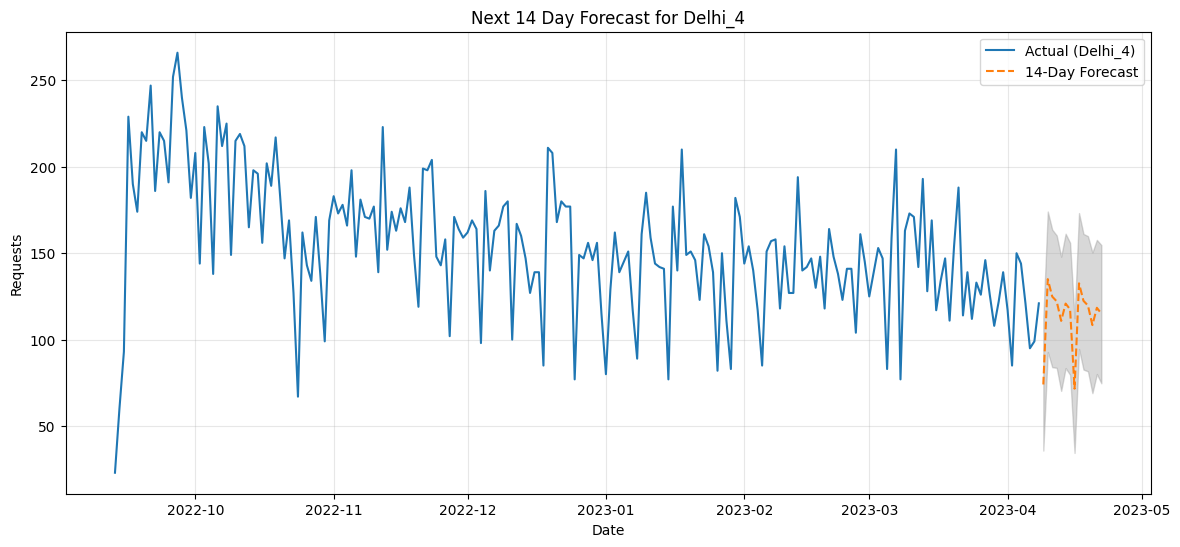

In [55]:
plt.figure(figsize=(14,6))

plt.plot(df_prophet["ds"], df_prophet["y"], label="Actual (Delhi_4)")

plt.plot(future_only_14["ds"], future_only_14["yhat"],label="14-Day Forecast", linestyle="--")

plt.fill_between(future_only_14["ds"], future_only_14["yhat_lower"],future_only_14["yhat_upper"], color="gray", alpha=0.3)

plt.title("Next 14 Day Forecast for Delhi_4")
plt.xlabel("Date")
plt.ylabel("Requests")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
